In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
from tabulate import tabulate
import csv

E.longa konwencjonalne
60
E.gracilis konwencjonalne
60
E.hiemalis konwencjonalne
60


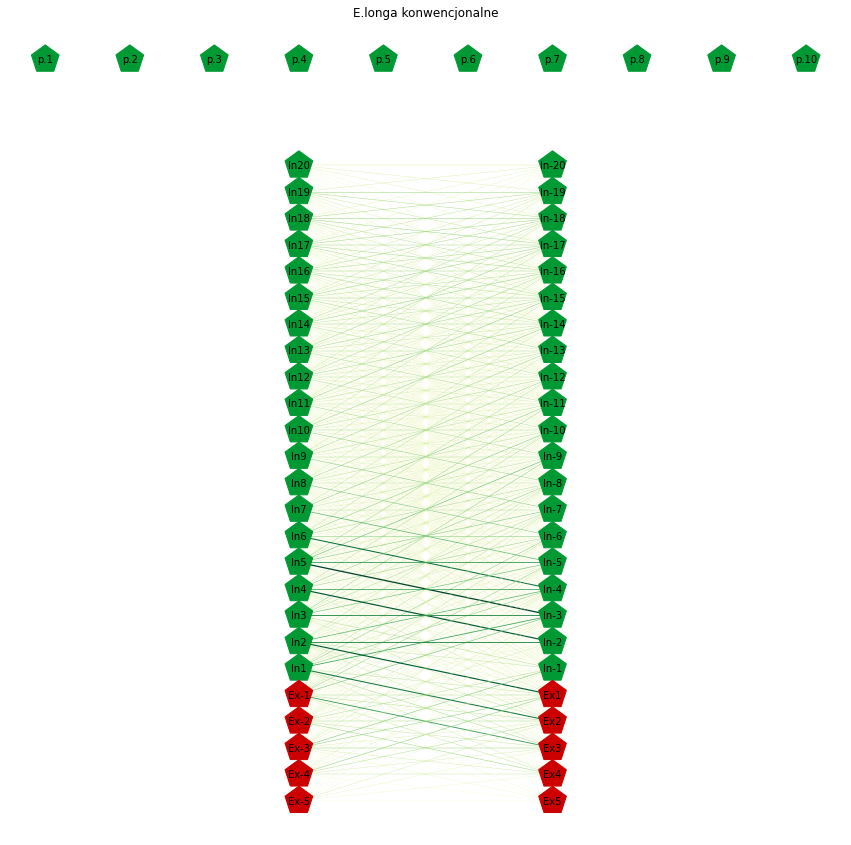

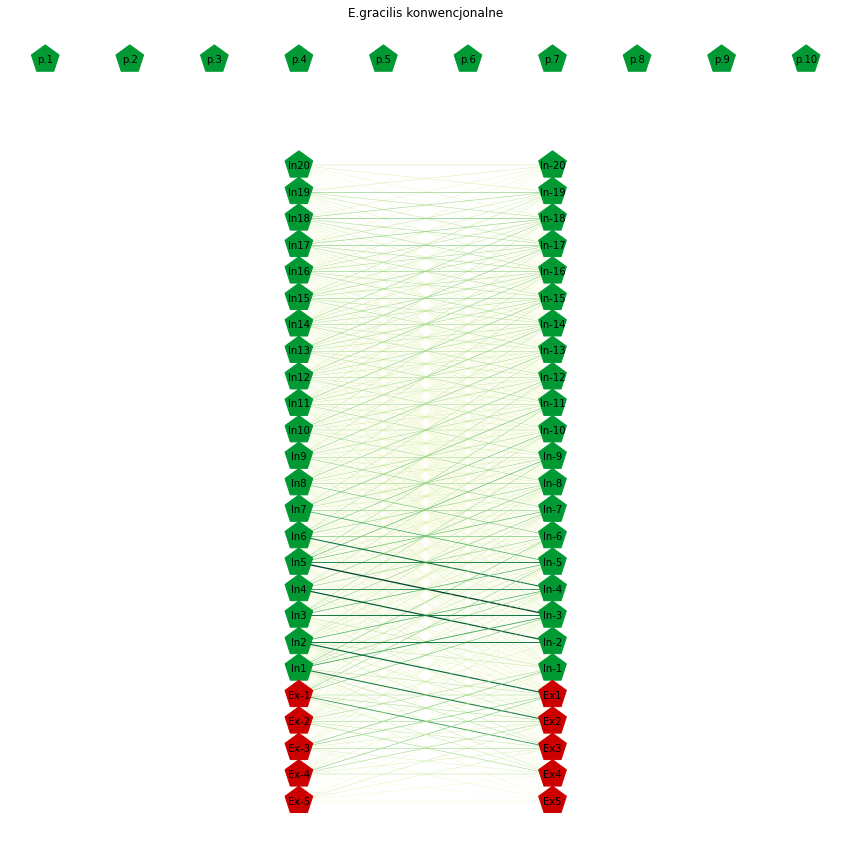

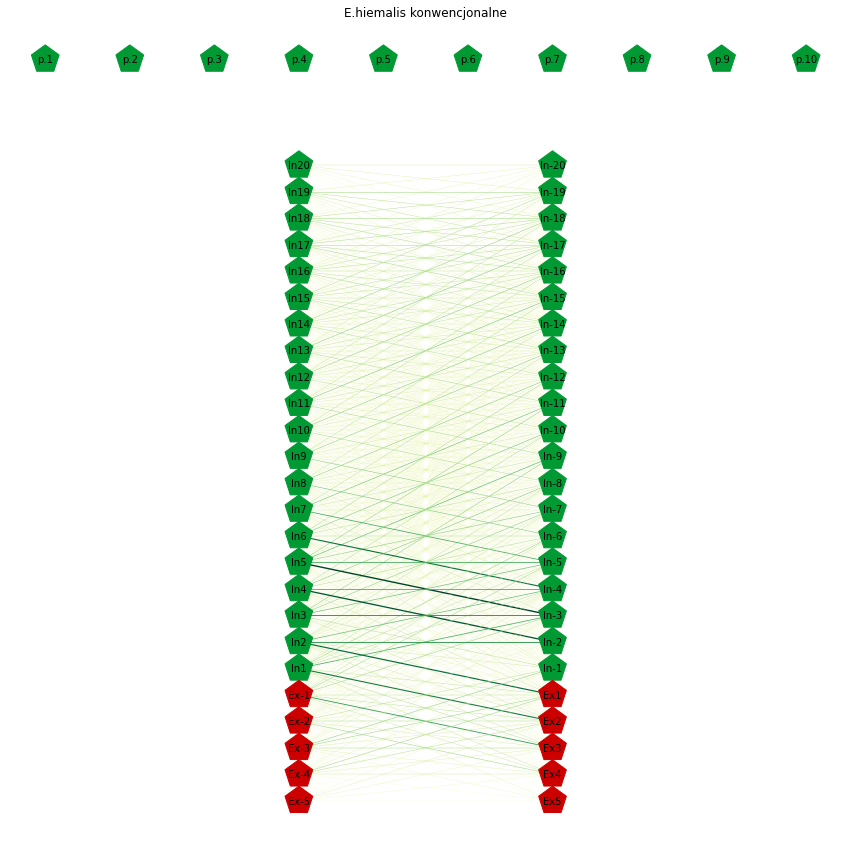

In [5]:
def index_to_label(i):
    if i in range(0,5):
        return "Ex"+str(i-5)
    if i in range(5,25):
        return "In"+str(i-4)
    if i in range(25,35):
        return "p."+str(i-24)
    if i in range(35,55):
        return "In"+str(i-55)
    if i in range(55,60):
        return "Ex"+str(i-54)

directory = './introny_joinedends/joinedends_struktury/'
for filename in os.listdir(directory):
    tytul=" ".join(filename[:-4].split("_"))
    parowanie_w_petli, zly_nawias=0,0
    #if not filename.endswith(".dbn") or filename.endswith('35.dbn') or filename.startswith("E."):
    if not filename.endswith("konwencjonalne.dbn"):
        #print(os.path.join(directory, filename))
        continue
    
    print(tytul)
    plik=open(directory+filename,'r').readlines()
    struktury=[i.split(" ")[0] for i in plik[2::3]]
    czestosc=np.zeros((60,60))
    for struktura in struktury:
        #print(len(struktura))
        pary,stos=[],[]
        for aa in range(len(struktura)):
            if struktura[aa]=="(": stos.append(aa)
            elif struktura[aa]==")":
                a=stos.pop()
                pary.append((a, aa))
        for para1,para2 in pary:
            czestosc[para1, para2]+=1  
    
    G = nx.Graph()
    for pozycja in range(25,-1,-1):
        G.add_node(pozycja, pos=(0,pozycja))
        G.add_node(59-pozycja, pos=(3,pozycja))
    for i in range(25,35):
        G.add_node(i, pos=(i-28, 28))
    for index in np.ndindex(czestosc.shape):
        w=czestosc[index]
        if w!=0: G.add_edge(index[0], index[1], weight=w)
    
    d=len(struktury)#np.max(czestosc)#np.sum(czestosc)
    czestosc=czestosc/d*100
    
    headers = [index_to_label(i) for i in range(len(czestosc))]
    ps = ["p."+str(i) for i in range(1,11)]
    print(len(headers))
    t = pd.DataFrame({headers[i]:czestosc[:,i] for i in range(60)}, index=headers)
    t.drop(ps, axis=0, inplace=True)
    t.drop(ps, axis=1, inplace=True)
    #print(t.shape, t.columns, t.index)

    table=t.to_csv(sep=",")
    with open(directory+'tabele/%s_tabela.csv' %(tytul.replace(" ", "_")), 'w') as f:
    #with open(directory+'rysunki/table.csv', 'w') as f:
        f.write(table)
    
    mapping={node:index_to_label(node) for node in G.nodes()}
    G = nx.relabel_nodes(G, mapping)
    
    plt.figure(figsize=(15,15))
    plt.title(tytul)
    pos, weights = nx.get_node_attributes(G,'pos'), nx.get_edge_attributes(G, 'weight')
    edges,weights = zip(*nx.get_edge_attributes(G,'weight').items())
    
    edges = G.edges()
    allweights = sum([G[u][v]['weight'] for u,v in edges])
    colors = [G[u][v]['weight'] for u,v in edges]
    node_colors=['#cc0000' if node.startswith('Ex') else '#009933' for node in G.nodes()]
    weights = [G[u][v]['weight']/allweights*250 for u,v in edges]
    nx.draw(G, pos, edgelist=edges, node_size=850, node_color=node_colors, font_size=10, node_shape='p', edge_color=colors, width=weights, with_labels=True, edge_cmap=plt.cm.YlGn)
    plt.savefig(directory+'rysunki/%s_graph.png' %(tytul.replace(" ", "_")))
    #plt.show()

In [4]:
'''to samo tylko dla dluzszych intronow'''

def index_to_label_2(i):
    if i in range(0,5):
        return "Ex"+str(i-5)
    if i in range(5,35):
        return "In"+str(i-4)
    if i in range(35,45):
        return "p."+str(i-34)
    if i in range(45,75):
        return "In"+str(i-75)
    if i in range(75,80):
        return "Ex"+str(i-74)

directory = './introny_joinedends/joinedends_struktury/'
for filename in os.listdir(directory):
    tytul=" ".join(filename[:-4].split("_"))
    parowanie_w_petli, zly_nawias=0,0
    if not filename.endswith("35.dbn") or not filename.startswith("unmoved-onesided"): continue
    
    print(tytul)
    plik=open(directory+filename,'r').readlines()
    struktury=[i.split(" ")[0] for i in plik[2::3]]
    czestosc=np.zeros((80,80))
    for struktura in struktury:
        pary,stos=[],[]
        for aa in range(len(struktura)):
            if struktura[aa]=="(": stos.append(aa)
            elif struktura[aa]==")":
                a=stos.pop()
                pary.append((a, aa))
        for para1,para2 in pary:
            czestosc[para1, para2]+=1
    
    d=len(struktury)#np.sum(czestosc)#np.max(czestosc)
    czestosc=czestosc/d*100
    print(np.amax(czestosc))
    
    
    headers = [index_to_label_2(i) for i in range(len(czestosc))]
    t = pd.DataFrame({headers[i]:czestosc[:,i] for i in range(80)}, index=headers)
    t.drop(ps, axis=0, inplace=True)
    t.drop(ps, axis=1, inplace=True)
    
    #print(t.shape)
    table=t.to_csv(sep=",")
    with open(directory+'tabele/%s_tabela.csv' %(tytul.replace(" ", "_")), 'w') as f:
        f.write(table)

    '''G = nx.Graph()
    for pozycja in range(35,-1,-1):
        G.add_node(pozycja, pos=(0,pozycja))
        G.add_node(79-pozycja, pos=(3,pozycja))
    for i in range(35,45):
        G.add_node(i, pos=(i-38, 38))
    for index in np.ndindex(czestosc.shape):
        w=czestosc[index]
        if w!=0: G.add_edge(index[0],index[1], weight=w)
    
    mapping={node:index_to_label_2(node) for node in G.nodes()}
    G = nx.relabel_nodes(G, mapping)
    
    plt.figure(figsize=(15,15))
    plt.title(tytul)
    pos, weights = nx.get_node_attributes(G,'pos'), nx.get_edge_attributes(G, 'weight')
    edges,weights = zip(*nx.get_edge_attributes(G,'weight').items())
    
    edges = G.edges()
    allweights = sum([G[u][v]['weight'] for u,v in edges])
    colors = [G[u][v]['weight'] for u,v in edges]
    weights = [G[u][v]['weight']/allweights*500 for u,v in edges]
    node_colors=['#cc0000' if node.startswith('Ex') else '#009933' for node in G.nodes()] #'#33cc33'
    nx.draw(G, pos, edgelist=edges, node_size=850, node_color=node_colors, font_size=10, edge_color=colors, width=weights, with_labels=True, edge_cmap=plt.cm.YlGn)
    plt.savefig(directory+'rysunki/%s_graph.png' %(tytul.replace(" ", "_")))
    #plt.show()'''

unmoved-onesided E.hiemalis joinedends 35
20.30541847114513
unmoved-onesided E.longa joinedends 35
27.123937090827
unmoved-onesided E.gracilis joinedends 35
25.886069601845353


In [552]:
print([node.startswith('In') for node in G.nodes()])

[False, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]
